In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
career_data = pd.read_csv(r"D:\udit jain\AI career recommendation\dataset\processed\career_ml_dataset.csv")
career_data.head()

,occupation_code,career,description,skill_active_learning,skill_active_listening,skill_critical_thinking,skill_learning_strategies,skill_mathematics,skill_monitoring,skill_reading_comprehension,...,ability_visualization,ability_wrist_finger_speed,ability_written_comprehension,ability_written_expression,interest_artistic,interest_conventional,interest_enterprising,interest_investigative,interest_realistic,interest_social
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,3.75,4.00,4.38,3.12,3.25,4.00,4.12,...,3.00,1.38,4.25,4.12,2.16,4.97,6.96,3.05,1.26,3.54
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...",3.75,4.00,4.12,3.38,2.88,3.75,4.00,...,2.75,1.12,4.00,4.12,2.48,4.49,6.68,4.78,2.04,3.55
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...",3.62,4.00,3.88,3.00,2.62,4.00,4.00,...,2.75,1.75,4.00,4.00,1.29,5.34,7.00,2.37,2.20,3.38
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.70,3.62,5.52,3.35,1.54,3.69
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...",3.38,4.12,3.88,3.00,2.88,3.50,3.75,...,2.88,1.62,4.00,4.00,3.87,4.43,7.00,1.69,1.00,3.14


In [3]:
career_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 71 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   occupation_code                      1016 non-null   object 
 1   career                               1016 non-null   object 
 2   description                          1016 non-null   object 
 3   skill_active_learning                910 non-null    float64
 4   skill_active_listening               910 non-null    float64
 5   skill_critical_thinking              910 non-null    float64
 6   skill_learning_strategies            910 non-null    float64
 7   skill_mathematics                    910 non-null    float64
 8   skill_monitoring                     910 non-null    float64
 9   skill_reading_comprehension          910 non-null    float64
 10  skill_science                        910 non-null    float64
 11  skill_speaking                

In [4]:
career_data.isnull().sum()

occupation_code             0
career                      0
description                 0
skill_active_learning     106
skill_active_listening    106
                         ... 
interest_conventional      93
interest_enterprising      93
interest_investigative     93
interest_realistic         93
interest_social            93
Length: 71, dtype: int64

In [5]:
career_data.shape

(1016, 71)

In [6]:
numeric_columns=career_data.select_dtypes(include=["float64","int64"]).columns
career_data[numeric_columns]=career_data[numeric_columns].fillna(career_data[numeric_columns].mean())

In [7]:
career_data.isnull().sum()

occupation_code           0
career                    0
description               0
skill_active_learning     0
skill_active_listening    0
                         ..
interest_conventional     0
interest_enterprising     0
interest_investigative    0
interest_realistic        0
interest_social           0
Length: 71, dtype: int64

In [8]:
career_data.head()

,occupation_code,career,description,skill_active_learning,skill_active_listening,skill_critical_thinking,skill_learning_strategies,skill_mathematics,skill_monitoring,skill_reading_comprehension,...,ability_visualization,ability_wrist_finger_speed,ability_written_comprehension,ability_written_expression,interest_artistic,interest_conventional,interest_enterprising,interest_investigative,interest_realistic,interest_social
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,3.750000,4.000,4.380000,3.120000,3.25000,4.000000,4.120000,...,3.000000,1.380000,4.250000,4.120000,2.16,4.97,6.96,3.05,1.26,3.54
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...",3.750000,4.000,4.120000,3.380000,2.88000,3.750000,4.000000,...,2.750000,1.120000,4.000000,4.120000,2.48,4.49,6.68,4.78,2.04,3.55
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...",3.620000,4.000,3.880000,3.000000,2.62000,4.000000,4.000000,...,2.750000,1.750000,4.000000,4.000000,1.29,5.34,7.00,2.37,2.20,3.38
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...",3.121824,3.596,3.517912,2.787209,2.55278,3.309604,3.490626,...,2.757912,1.880868,3.537593,3.327495,2.70,3.62,5.52,3.35,1.54,3.69
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...",3.380000,4.120,3.880000,3.000000,2.88000,3.500000,3.750000,...,2.880000,1.620000,4.000000,4.000000,3.87,4.43,7.00,1.69,1.00,3.14


In [9]:
career_data.duplicated().sum()

np.int64(0)

In [10]:
career_data['occupation_code'].duplicated().sum()

np.int64(0)

In [11]:
print(career_data.dtypes)

occupation_code            object
career                     object
description                object
skill_active_learning     float64
skill_active_listening    float64
                           ...   
interest_conventional     float64
interest_enterprising     float64
interest_investigative    float64
interest_realistic        float64
interest_social           float64
Length: 71, dtype: object


In [12]:
career_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 71 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   occupation_code                      1016 non-null   object 
 1   career                               1016 non-null   object 
 2   description                          1016 non-null   object 
 3   skill_active_learning                1016 non-null   float64
 4   skill_active_listening               1016 non-null   float64
 5   skill_critical_thinking              1016 non-null   float64
 6   skill_learning_strategies            1016 non-null   float64
 7   skill_mathematics                    1016 non-null   float64
 8   skill_monitoring                     1016 non-null   float64
 9   skill_reading_comprehension          1016 non-null   float64
 10  skill_science                        1016 non-null   float64
 11  skill_speaking                

In [13]:
import os
output_file=os.path.join(r"D:\udit jain\AI career recommendation\dataset\processed","career_ml_dataset_clean.csv")
career_data.to_csv(output_file,index=False)

In [14]:
career_data_clean = pd.read_csv(r"D:\udit jain\AI career recommendation\dataset\processed\career_ml_dataset_clean.csv")
career_data.head()

,occupation_code,career,description,skill_active_learning,skill_active_listening,skill_critical_thinking,skill_learning_strategies,skill_mathematics,skill_monitoring,skill_reading_comprehension,...,ability_visualization,ability_wrist_finger_speed,ability_written_comprehension,ability_written_expression,interest_artistic,interest_conventional,interest_enterprising,interest_investigative,interest_realistic,interest_social
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,3.750000,4.000,4.380000,3.120000,3.25000,4.000000,4.120000,...,3.000000,1.380000,4.250000,4.120000,2.16,4.97,6.96,3.05,1.26,3.54
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...",3.750000,4.000,4.120000,3.380000,2.88000,3.750000,4.000000,...,2.750000,1.120000,4.000000,4.120000,2.48,4.49,6.68,4.78,2.04,3.55
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...",3.620000,4.000,3.880000,3.000000,2.62000,4.000000,4.000000,...,2.750000,1.750000,4.000000,4.000000,1.29,5.34,7.00,2.37,2.20,3.38
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...",3.121824,3.596,3.517912,2.787209,2.55278,3.309604,3.490626,...,2.757912,1.880868,3.537593,3.327495,2.70,3.62,5.52,3.35,1.54,3.69
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...",3.380000,4.120,3.880000,3.000000,2.88000,3.500000,3.750000,...,2.880000,1.620000,4.000000,4.000000,3.87,4.43,7.00,1.69,1.00,3.14


In [15]:
career_data_clean.shape

(1016, 71)

In [49]:
info_columns=[
    "occupation_code",
    "career",
    "description"
]
feature_columns=[col for col in career_data_clean.columns if col not in info_columns ]
x=career_data_clean[feature_columns]
print(len(feature_columns))
print(x.shape)



68
(1016, 68)


In [50]:
for i,feature in enumerate(feature_columns):
    print(i,feature)

0 skill_active_learning
1 skill_active_listening
2 skill_critical_thinking
3 skill_learning_strategies
4 skill_mathematics
5 skill_monitoring
6 skill_reading_comprehension
7 skill_science
8 skill_speaking
9 skill_writing
10 ability_arm_hand_steadiness
11 ability_auditory_attention
12 ability_category_flexibility
13 ability_control_precision
14 ability_deductive_reasoning
15 ability_depth_perception
16 ability_dynamic_flexibility
17 ability_dynamic_strength
18 ability_explosive_strength
19 ability_extent_flexibility
20 ability_far_vision
21 ability_finger_dexterity
22 ability_flexibility_of_closure
23 ability_fluency_of_ideas
24 ability_glare_sensitivity
25 ability_gross_body_coordination
26 ability_gross_body_equilibrium
27 ability_hearing_sensitivity
28 ability_inductive_reasoning
29 ability_information_ordering
30 ability_manual_dexterity
31 ability_mathematical_reasoning
32 ability_memorization
33 ability_multilimb_coordination
34 ability_near_vision
35 ability_night_vision
36 abili

In [17]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
skill_active_learning,1016.0,3.121824,0.515875,1.88,2.88,3.120000,3.5000,4.50
skill_active_listening,1016.0,3.596000,0.444888,2.00,3.12,3.620000,4.0000,5.00
skill_critical_thinking,1016.0,3.517912,0.443235,2.25,3.12,3.517912,3.8800,4.88
skill_learning_strategies,1016.0,2.787209,0.549387,1.12,2.38,2.787209,3.0000,4.88
skill_mathematics,1016.0,2.552780,0.565371,1.00,2.12,2.552780,2.8800,5.00
...,...,...,...,...,...,...,...,...
interest_conventional,1016.0,4.525135,0.947765,1.61,3.80,4.525135,5.0625,7.00
interest_enterprising,1016.0,2.825038,1.536332,1.00,1.61,2.565000,3.5725,7.00
interest_investigative,1016.0,3.361257,1.603580,1.00,2.11,3.265000,4.5700,7.00
interest_realistic,1016.0,4.572438,1.838098,1.00,3.09,4.572438,6.2725,7.00


In [18]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(x)
X_scaled.shape

(1016, 68)

In [19]:
X_scaled_df=pd.DataFrame(X_scaled,columns=feature_columns)
X_scaled_df.head()

,skill_active_learning,skill_active_listening,skill_critical_thinking,skill_learning_strategies,skill_mathematics,skill_monitoring,skill_reading_comprehension,skill_science,skill_speaking,skill_writing,...,ability_visualization,ability_wrist_finger_speed,ability_written_comprehension,ability_written_expression,interest_artistic,interest_conventional,interest_enterprising,interest_investigative,interest_realistic,interest_social
0,1.218289,0.908542,1.945949e+00,0.606048,1.233815e+00,1.851333,1.180302e+00,-0.366810,1.512827,1.515618e+00,...,4.998812e-01,-1.223092,1.275862,1.278546e+00,0.195596,0.469614,2.692777,-0.194197,-1.802988,0.358327
1,1.218289,0.908542,1.359064e+00,1.079536,5.790550e-01,1.180944,9.552590e-01,0.223397,0.982497,1.515618e+00,...,-1.633747e-02,-1.857998,0.828132,1.278546e+00,0.475250,-0.037090,2.510435,0.885171,-1.378427,0.364336
2,0.966166,0.908542,8.173234e-01,0.387516,1.189535e-01,1.851333,9.552590e-01,-0.508460,0.982497,5.019360e-01,...,-1.633747e-02,-0.319573,0.828132,1.084950e+00,-0.564716,0.860198,2.718826,-0.618457,-1.291338,0.262187
3,0.000000,0.000000,1.002421e-15,0.000000,7.858696e-16,0.000000,1.665654e-15,0.000000,0.000000,7.260728e-16,...,-9.169886e-16,0.000000,0.000000,-7.164473e-16,0.667513,-0.955491,1.755018,-0.007023,-1.650582,0.448459
4,0.500708,1.178406,8.173234e-01,0.387516,5.790550e-01,0.510556,4.864190e-01,-0.508460,1.237055,9.106787e-01,...,2.520963e-01,-0.637025,0.828132,1.084950e+00,1.690001,-0.100428,2.718826,-1.042717,-1.944508,0.117976


In [20]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
kf.n_splits

5

In [21]:
approaches=["Random Forest",
           "XGBoost",
           "Logistic Regression",
           "KNN",
           "Cosine Similarity",
           "K-Means",
           "PCA"]
print("Candidate Approaches:")
for i,approaches in enumerate(approaches,start=1):
    print(f"{i}.{approaches}")

Candidate Approaches:
1.Random Forest
2.XGBoost
3.Logistic Regression
4.KNN
5.Cosine Similarity
6.K-Means
7.PCA


In [22]:
print("Original features:")
print(x.shape)

print("\nScaled features:")
print(X_scaled.shape)

print("\nNumber of features:")
print(len(feature_columns))

Original features:
(1016, 68)

Scaled features:
(1016, 68)

Number of features:
68


In [23]:
print("\nFeature groups:")

skill_features = [col for col in feature_columns if col.startswith("skill_")]
ability_features = [col for col in feature_columns if col.startswith("ability_")]
interest_features = [col for col in feature_columns if col.startswith("interest_")]

print("Skills:", len(skill_features))
print("Abilities:", len(ability_features))
print("Interests:", len(interest_features))


Feature groups:
Skills: 10
Abilities: 52
Interests: 6


In [24]:
test_index=100
student_profile=x.iloc[test_index].values
student_profile.shape
career_data_clean.iloc[test_index]['career']

'Financial Risk Specialists'

In [25]:
student_profile_scaled=scaler.transform(pd.DataFrame([student_profile],columns=feature_columns))
student_profile_scaled.shape

(1, 68)

In [26]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_score=cosine_similarity(student_profile_scaled,X_scaled)[0]
print(len(similarity_score))
print(similarity_score.max())

1016
0.9999999999999998


In [27]:
top_indicies=np.argsort(similarity_score)[::-1][:5]
recommendation=career_data_clean.iloc[top_indicies][["occupation_code","career"]].copy()
recommendation["similarity_score"]=similarity_score[top_indicies]
recommendation

,occupation_code,career,similarity_score
100,13-2054.00,Financial Risk Specialists,1.000000
97,13-2051.00,Financial and Investment Analysts,0.983125
501,29-9021.00,Health Information Technologists and Medical R...,0.633398
3,11-1031.00,Legislators,0.529151
9,11-3012.00,Administrative Services Managers,0.451768


In [28]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(X_scaled)

print("KNN model fitted successfully.")

KNN model fitted successfully.


In [29]:
distances, indices = knn.kneighbors(
    student_profile_scaled
)
print("Distances:")
print(distances)
print("\nIndices:")
print(indices)

Distances:
[[0.         0.61078659 2.11161926 2.5506594  2.5506594 ]]

Indices:
[[100  97 501  33  49]]


In [30]:
knn_recommendations = career_data_clean.iloc[indices[0]][
    ["occupation_code", "career"]
].copy()

knn_recommendations["distance"] = distances[0]

knn_recommendations

,occupation_code,career,distance
100,13-2054.00,Financial Risk Specialists,0.000000
97,13-2051.00,Financial and Investment Analysts,0.610787
501,29-9021.00,Health Information Technologists and Medical R...,2.111619
33,11-9039.00,"Education Administrators, All Other",2.550659
49,11-9179.00,"Personal Service Managers, All Other",2.550659


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertias = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

print("Testing completed.")

Testing completed.


In [32]:
for k, inertia, score in zip(
    k_values,
    inertias,
    silhouette_scores
):
    print(
        f"K={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette Score={score:.4f}"
    )

K=2 | Inertia=45588.34 | Silhouette Score=0.3037
K=3 | Inertia=39479.43 | Silhouette Score=0.2055
K=4 | Inertia=35987.72 | Silhouette Score=0.2023
K=5 | Inertia=33462.81 | Silhouette Score=0.1815
K=6 | Inertia=31670.82 | Silhouette Score=0.1728
K=7 | Inertia=30143.15 | Silhouette Score=0.1763
K=8 | Inertia=28893.50 | Silhouette Score=0.1667
K=9 | Inertia=28130.02 | Silhouette Score=0.1607
K=10 | Inertia=27446.43 | Silhouette Score=0.1571


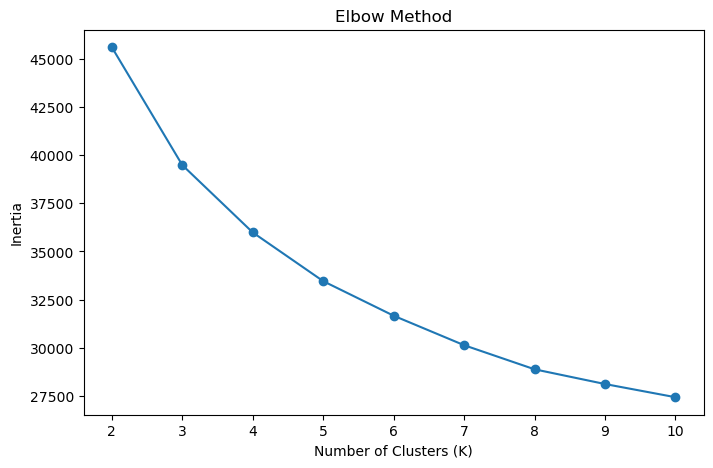

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

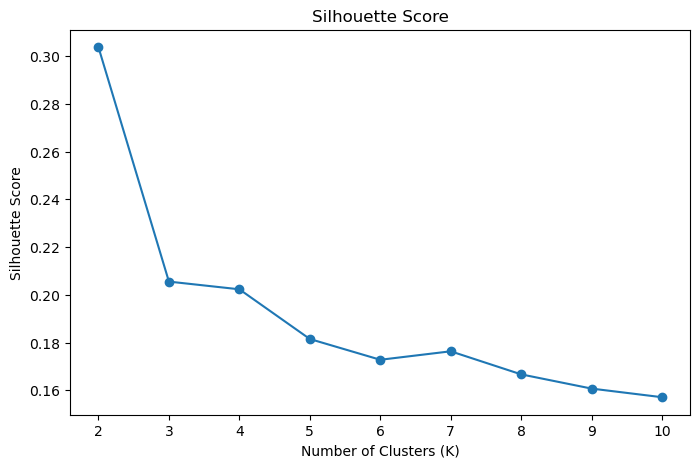

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [35]:
from sklearn.decomposition import PCA
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("PCA components:", X_pca.shape[1])

Original features: 68
PCA components: 68


In [36]:
explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"Components: {i} | Cumulative Variance: {variance:.4f}")

Components: 1 | Cumulative Variance: 0.4668
Components: 2 | Cumulative Variance: 0.6325
Components: 3 | Cumulative Variance: 0.6965
Components: 4 | Cumulative Variance: 0.7375
Components: 5 | Cumulative Variance: 0.7665
Components: 6 | Cumulative Variance: 0.7925
Components: 7 | Cumulative Variance: 0.8135
Components: 8 | Cumulative Variance: 0.8278
Components: 9 | Cumulative Variance: 0.8405
Components: 10 | Cumulative Variance: 0.8515
Components: 11 | Cumulative Variance: 0.8612
Components: 12 | Cumulative Variance: 0.8698
Components: 13 | Cumulative Variance: 0.8782
Components: 14 | Cumulative Variance: 0.8852
Components: 15 | Cumulative Variance: 0.8920
Components: 16 | Cumulative Variance: 0.8985
Components: 17 | Cumulative Variance: 0.9047
Components: 18 | Cumulative Variance: 0.9104
Components: 19 | Cumulative Variance: 0.9157
Components: 20 | Cumulative Variance: 0.9204
Components: 21 | Cumulative Variance: 0.9249
Components: 22 | Cumulative Variance: 0.9294
Components: 23 | Cu

In [37]:

components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components for 90% variance:", components_90)
print("Components for 95% variance:", components_95)

Components for 90% variance: 17
Components for 95% variance: 28


In [38]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# PCA with 90% information
pca_90 = PCA(n_components=17)

X_pca_90 = pca_90.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca_90.shape)

Original shape: (1016, 68)
PCA shape: (1016, 17)


In [39]:

# Transform the test student profile
student_pca = pca_90.transform(student_profile_scaled)

# KNN on PCA features
knn_pca = NearestNeighbors(
    n_neighbors=5,
    metric="euclidean"
)

knn_pca.fit(X_pca_90)

distances_pca, indices_pca = knn_pca.kneighbors(
    student_pca
)

pca_knn_recommendations = career_data_clean.iloc[indices_pca[0]][
    ["occupation_code", "career"]
].copy()

pca_knn_recommendations["distance"] = distances_pca[0]

pca_knn_recommendations

,occupation_code,career,distance
100,13-2054.00,Financial Risk Specialists,2.107342e-08
97,13-2051.00,Financial and Investment Analysts,3.239490e-01
958,53-3054.00,Taxi Drivers,1.068888e+00
501,29-9021.00,Health Information Technologists and Medical R...,1.316571e+00
33,11-9039.00,"Education Administrators, All Other",1.341167e+00


In [40]:
np.random.seed(42)
test_indices = np.random.choice(
    len(career_data_clean),
    size=20,
    replace=False
)
print("Number of test profiles:", len(test_indices))
print("Test indices:", test_indices)

Number of test profiles: 20
Test indices: [753 519 210 943 915 534 810 199 215 589 595 429 547 598 741 405 883 355
 580 824]


In [41]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

top1 = 0
top3 = 0
top5 = 0

for test_index in test_indices:

    # Use one career profile as the student profile
    student_profile = x.iloc[test_index].values.reshape(1, -1)

    # Scale the student profile
    student_scaled = scaler.transform(student_profile)

    # Calculate similarity with all careers
    similarities = cosine_similarity(
        student_scaled,
        X_scaled
    )[0]

    # Remove the actual career from recommendations
    similarities[test_index] = -1

    # Rank careers by similarity
    ranked_indices = np.argsort(similarities)[::-1]

    # Check whether the actual career's profile
    # is represented by a similar career
    actual_profile = X_scaled[test_index]

    actual_similarities = cosine_similarity(
        actual_profile.reshape(1, -1),
        X_scaled
    )[0]

    actual_similarities[test_index] = -1

    actual_rank = np.where(
        ranked_indices == np.argmax(actual_similarities)
    )[0][0] + 1

    if actual_rank <= 1:
        top1 += 1

    if actual_rank <= 3:
        top3 += 1

    if actual_rank <= 5:
        top5 += 1


print("Cosine Similarity Evaluation")
print("----------------------------")
print("Top-1:", top1, "/", len(test_indices))
print("Top-3:", top3, "/", len(test_indices))
print("Top-5:", top5, "/", len(test_indices))

print()
print("Top-1 %:", (top1 / len(test_indices)) * 100)
print("Top-3 %:", (top3 / len(test_indices)) * 100)
print("Top-5 %:", (top5 / len(test_indices)) * 100)

Cosine Similarity Evaluation
----------------------------
Top-1: 19 / 20
Top-3: 19 / 20
Top-5: 19 / 20

Top-1 %: 95.0
Top-3 %: 95.0
Top-5 %: 95.0


In [42]:
from sklearn.neighbors import NearestNeighbors
top1 = 0
top3 = 0
top5 = 0

for test_index in test_indices:

    # Student profile
    student_profile = x.iloc[test_index].values.reshape(1, -1)

    # Scale profile
    student_scaled = scaler.transform(student_profile)

    # Remove the actual career from training candidates
    X_candidates = np.delete(X_scaled, test_index, axis=0)

    # KNN
    knn_eval = NearestNeighbors(
        n_neighbors=5,
        metric="euclidean"
    )

    knn_eval.fit(X_candidates)

    distances, indices = knn_eval.kneighbors(student_scaled)

    # Map candidate indices back to original dataset indices
    original_indices = [
        i for i in range(len(career_data_clean))
        if i != test_index
    ]

    recommended_indices = [
        original_indices[i]
        for i in indices[0]
    ]

    # Find the most similar career using cosine similarity
    similarities = cosine_similarity(
        student_scaled,
        X_scaled
    )[0]

    similarities[test_index] = -1

    expected_index = np.argmax(similarities)

    # Rank of expected career
    if expected_index in recommended_indices:
        rank = recommended_indices.index(expected_index) + 1
    else:
        rank = 999

    if rank <= 1:
        top1 += 1

    if rank <= 3:
        top3 += 1

    if rank <= 5:
        top5 += 1


print("KNN Evaluation")
print("----------------")
print("Top-1:", top1, "/", len(test_indices))
print("Top-3:", top3, "/", len(test_indices))
print("Top-5:", top5, "/", len(test_indices))

print()
print("Top-1 %:", (top1 / len(test_indices)) * 100)
print("Top-3 %:", (top3 / len(test_indices)) * 100)
print("Top-5 %:", (top5 / len(test_indices)) * 100)

KNN Evaluation
----------------
Top-1: 8 / 20
Top-3: 10 / 20
Top-5: 13 / 20

Top-1 %: 40.0
Top-3 %: 50.0
Top-5 %: 65.0


In [43]:
top1 = 0
top3 = 0
top5 = 0

for test_index in test_indices:

    # Student profile
    student_profile = x.iloc[test_index].values.reshape(1, -1)

    # Scale
    student_scaled = scaler.transform(student_profile)

    # PCA transformation
    student_pca = pca_90.transform(student_scaled)

    # Remove actual career
    X_candidates = np.delete(X_pca_90, test_index, axis=0)

    # KNN
    knn_eval = NearestNeighbors(
        n_neighbors=5,
        metric="euclidean"
    )

    knn_eval.fit(X_candidates)

    distances, indices = knn_eval.kneighbors(student_pca)

    # Map candidate indices back to original indices
    original_indices = [
        i for i in range(len(career_data_clean))
        if i != test_index
    ]

    recommended_indices = [
        original_indices[i]
        for i in indices[0]
    ]

    # Expected similar career using cosine similarity
    similarities = cosine_similarity(
        student_scaled,
        X_scaled
    )[0]

    similarities[test_index] = -1

    expected_index = np.argmax(similarities)

    if expected_index in recommended_indices:
        rank = recommended_indices.index(expected_index) + 1
    else:
        rank = 999

    if rank <= 1:
        top1 += 1

    if rank <= 3:
        top3 += 1

    if rank <= 5:
        top5 += 1


print("PCA + KNN Evaluation")
print("---------------------")
print("Top-1:", top1, "/", len(test_indices))
print("Top-3:", top3, "/", len(test_indices))
print("Top-5:", top5, "/", len(test_indices))

print()
print("Top-1 %:", (top1 / len(test_indices)) * 100)
print("Top-3 %:", (top3 / len(test_indices)) * 100)
print("Top-5 %:", (top5 / len(test_indices)) * 100)

PCA + KNN Evaluation
---------------------
Top-1: 3 / 20
Top-3: 10 / 20
Top-5: 12 / 20

Top-1 %: 15.0
Top-3 %: 50.0
Top-5 %: 60.0


In [44]:
from sklearn.ensemble import RandomForestRegressor
target_column = feature_columns[0]

X_rf = x.drop(columns=[target_column])
y_rf = x[target_column]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_rf, y_rf)

importance = pd.DataFrame({
    "feature": X_rf.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(10)

,feature,importance
1,skill_critical_thinking,0.385734
2,skill_learning_strategies,0.096523
27,ability_inductive_reasoning,0.093503
60,ability_written_expression,0.092664
8,skill_writing,0.075038
13,ability_deductive_reasoning,0.048592
5,skill_reading_comprehension,0.030229
22,ability_fluency_of_ideas,0.025604
38,ability_originality,0.008739
59,ability_written_comprehension,0.007843


In [45]:
from xgboost import XGBRegressor
target_column = feature_columns[0]

X_xgb = x.drop(columns=[target_column])
y_xgb = x[target_column]

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_xgb, y_xgb)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [46]:
importance_xgb = pd.DataFrame({
    "feature": X_xgb.columns,
    "importance": xgb.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    "importance",
    ascending=False
)

importance_xgb.head(10)

,feature,importance
27,ability_inductive_reasoning,0.233274
1,skill_critical_thinking,0.230711
60,ability_written_expression,0.200784
13,ability_deductive_reasoning,0.049148
2,skill_learning_strategies,0.034245
22,ability_fluency_of_ideas,0.018946
8,skill_writing,0.015699
38,ability_originality,0.014478
59,ability_written_comprehension,0.012709
48,ability_speech_clarity,0.008654


In [47]:
import joblib
joblib.dump(scaler,r"D:\udit jain\AI career recommendation\Backend\ML\model\scaler.pkl")
print("Scaler saved successfully!")
joblib.dump(feature_columns,r"D:\udit jain\AI career recommendation\Backend\ML\model\feature_columns.pkl")
print("Feature columns saved successfully!")
import numpy as np
np.save(r"D:\udit jain\AI career recommendation\Backend\ML\model\X_scaled.npy",X_scaled)
print("Career feature matrix saved successfully!")
career_data_clean[ ["occupation_code", "career", "description"]].to_csv( r"D:\udit jain\AI career recommendation\Backend\ML\model\career_info.csv",
    index=False
)
print("Career information saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\udit jain\\AI career recommendation\\Backend\\ML\\model\\scaler.pkl'